

      INDIAN IT COMPANIES — RISK COMPARISON
Company  Return %  Daily Vol %  10-Day Vol %  VaR 95 %
    TCS    -6.25      4.40         13.91        6.52  
Infosys    -4.76      3.07          9.72        3.54  
  Wipro   -13.31      3.26         10.32        6.73  
HCLTech    -5.27      2.69          8.51        4.00  


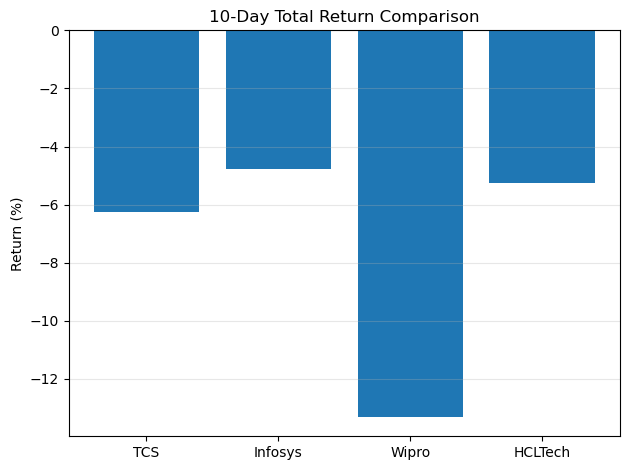

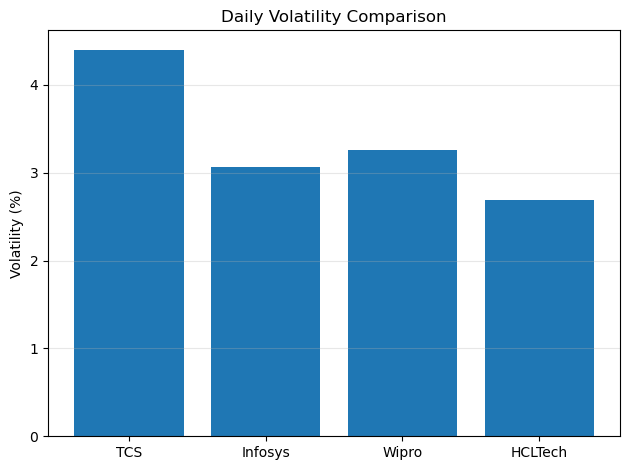

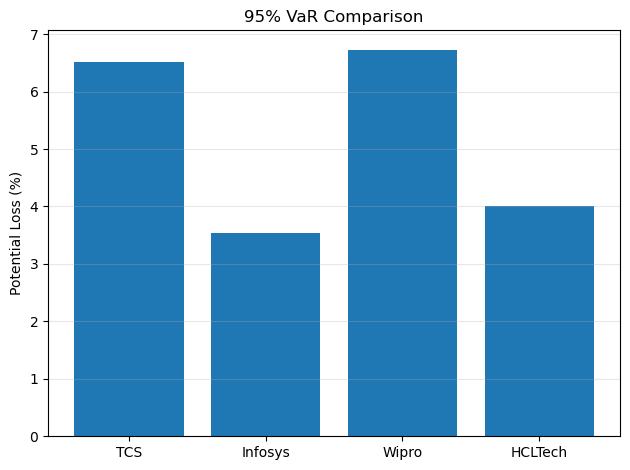


KEY TAKEAWAYS
----------------------------------------
Highest Return      : Infosys (-4.76%)
Highest Volatility  : TCS (4.4%)
Highest VaR Risk    : Wipro (6.73%)
----------------------------------------

Note:
Analysis is based on approximately 10 days of historical data.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# ============================================================
# 1. FILE PATHS
# ============================================================

files = {
    'TCS': r"C:\Users\ashi6\Downloads\NAVU DATA\Quote-Equity-TCS-EQ-01-06-2026-10-06-2026.csv",
    'Infosys': r"C:\Users\ashi6\Downloads\NAVU DATA\Quote-Equity-INFY-EQ-01-06-2026-10-06-2026.csv",
    'Wipro': r"C:\Users\ashi6\Downloads\NAVU DATA\Quote-Equity-WIPRO-EQ-01-06-2026-10-06-2026.csv",
    'HCLTech': r"C:\Users\ashi6\Downloads\NAVU DATA\Quote-Equity-HCLTECH-EQ-01-06-2026-10-06-2026.csv"
}

# ============================================================
# 2. PROCESS DATA
# ============================================================

results = []

for company, file in files.items():

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    df['DATE'] = pd.to_datetime(
        df['DATE'],
        format='%d-%b-%Y'
    )

    df['CLOSE'] = (
        df['CLOSE']
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

    df = (
        df[['DATE', 'CLOSE']]
        .sort_values('DATE')
        .reset_index(drop=True)
    )

    returns = df['CLOSE'].pct_change().dropna()

    daily_vol = returns.std()

    vol_10day = daily_vol * np.sqrt(10)

    var_95 = np.percentile(returns, 5)

    total_return = (
        df['CLOSE'].iloc[-1] /
        df['CLOSE'].iloc[0]
        - 1
    )

    results.append({
        'Company': company,
        'Return %': round(total_return * 100, 2),
        'Daily Vol %': round(daily_vol * 100, 2),
        '10-Day Vol %': round(vol_10day * 100, 2),
        'VaR 95 %': round(abs(var_95) * 100, 2)
    })

# ============================================================
# 3. SUMMARY TABLE
# ============================================================

summary = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("      INDIAN IT COMPANIES — RISK COMPARISON")
print("=" * 70)

print(
    summary.to_string(
        index=False,
        justify='center'
    )
)

print("=" * 70)

# ============================================================
# 4. BAR CHART — TOTAL RETURN
# ============================================================



plt.bar(
    summary['Company'],
    summary['Return %']
)

plt.title('10-Day Total Return Comparison')
plt.ylabel('Return (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 5. BAR CHART — DAILY VOLATILITY
# ============================================================



plt.bar(
    summary['Company'],
    summary['Daily Vol %']
)

plt.title('Daily Volatility Comparison')
plt.ylabel('Volatility (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 6. BAR CHART — VaR 95%
# ============================================================



plt.bar(
    summary['Company'],
    summary['VaR 95 %']
)

plt.title('95% VaR Comparison')
plt.ylabel('Potential Loss (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 7. BEST PERFORMER / MOST RISKY
# ============================================================

best_return = summary.loc[summary['Return %'].idxmax()]
highest_vol = summary.loc[summary['Daily Vol %'].idxmax()]
highest_var = summary.loc[summary['VaR 95 %'].idxmax()]

print("\nKEY TAKEAWAYS")
print("-" * 40)

print(
    f"Highest Return      : {best_return['Company']} "
    f"({best_return['Return %']}%)"
)

print(
    f"Highest Volatility  : {highest_vol['Company']} "
    f"({highest_vol['Daily Vol %']}%)"
)

print(
    f"Highest VaR Risk    : {highest_var['Company']} "
    f"({highest_var['VaR 95 %']}%)"
)

print("-" * 40)

print("\nNote:")
print("Analysis is based on approximately 10 days of historical data.")
